# 03_00 — Model Training: Feature Selection

**Pipeline:** `model_training`  
**Kedro nodes:** `build_training_data_node` → `train_isolation_forest_node` → `evaluate_model_node`  
**Input catalog:** `prepared_flights` (data/04_feature/)  
**Output catalog:** `isolation_forest`, `model_metrics`

---

## Contexto

Com os dados preparados, esta etapa treina um detector de anomalias não-supervisionado.
O objetivo é detectar a **falha do motor** o mais rápido possível após ela ocorrer.

### Por que Isolation Forest?

- Não requer dados rotulados para treinar (apenas o parâmetro `contamination`)
- Funciona bem com dados de alta dimensão e temporal
- Produz um **anomaly score** contínuo, não só uma classificação binária

### Fluxo da pipeline
1. **Skip inicial**: remove a fase de transição de altitude no início de cada voo
2. **Seleção de features**: Cohen's d ranqueia features por separabilidade fault vs normal
3. **Sliding windows**: cada amostra = últimos `window_size` timesteps achatados
4. **Treino**: Isolation Forest com split temporal 70/30
5. **Avaliação**: latência de detecção = tempo entre falha real e primeiro alerta

> **Para rodar toda a pipeline no Kedro:** `kedro run --pipeline=model_training`

## Imports e parâmetros

In [1]:
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroespacial_2.pipelines.model_training.nodes import (
    create_windows,
    evaluate_model,
    select_top_features_effect_size,
    split_windows,
    train_isolation_forest,
)

_params = yaml.safe_load(
    (Path("../../conf/base/parameters.yml")).read_text()
)["model_training"]

PREPARED_FILE  = "../../data/04_feature/carbonZ_2018-07-18-15-53-31_1_engine_failure.csv"
WINDOW_SIZE    = _params["window_size"]
N_TOP_FEATURES = _params["n_top_features"]
CONTAMINATION  = _params["contamination"]
N_ESTIMATORS   = _params["n_estimators"]
TRAIN_RATIO    = _params["train_ratio"]
TARGET_COL     = _params["target_col"]
TIMESTAMP_COL  = _params["timestamp_col"]
SKIP_SECONDS   = _params.get("skip_seconds", 0.0)

print("Parâmetros carregados de conf/base/parameters.yml:")
for k, v in _params.items():
    print(f"  {k}: {v}")

Parâmetros carregados de conf/base/parameters.yml:
  window_size: 20
  contamination: 0.001
  n_estimators: 100
  max_samples: 128
  max_features: 0.5
  n_top_features: 20
  train_ratio: 0.7
  target_col: target_fault
  timestamp_col: timestamp
  skip_seconds: 20.0


In [2]:
df_raw = pd.read_csv(PREPARED_FILE)

# Remove a fase de transição inicial (aeronave descendo para altitude de cruise)
df = df_raw[df_raw[TIMESTAMP_COL] >= SKIP_SECONDS].copy() if SKIP_SECONDS > 0 else df_raw.copy()

print(f"Shape original: {df_raw.shape}  →  após skip {SKIP_SECONDS}s: {df.shape}")
print(f"Falhas: {df[TARGET_COL].sum():.0f} amostras ({df[TARGET_COL].mean()*100:.1f}%)")
df.head(3)

Shape original: (25994, 207)  →  após skip 20.0s: (22031, 207)
Falhas: 3220 amostras (14.6%)


,timestamp,target_fault,dev_path_y,dev_path_z,ctrl_yaw_rate,nav_heading,alt_global,vel_z_local,alt_gps_fix,vel_x_gps,...,fft_high_ratio_energy_specific_2000,fft_peak_power_alt_global_500,fft_entropy_alt_global_500,fft_high_ratio_alt_global_500,fft_peak_power_alt_global_1000,fft_entropy_alt_global_1000,fft_high_ratio_alt_global_1000,fft_peak_power_alt_global_2000,fft_entropy_alt_global_2000,fft_high_ratio_alt_global_2000
3963,20.001260,0.0,0.74319,0.912159,0.062578,85.33,359.232698,-0.72,361.392697,17.518578,...,0.000989,45.278392,0.197730,0.002312,329.989735,0.290914,0.002156,2035.059141,0.097196,0.000171
3964,20.003843,0.0,0.74319,0.912159,0.062578,85.33,359.232698,-0.72,361.392697,17.518578,...,0.000991,45.196526,0.197140,0.002354,327.944477,0.292229,0.002173,2034.143922,0.097199,0.000171
3965,20.006855,0.0,0.74319,0.912159,0.062578,86.16,359.552754,-0.91,361.392697,17.518578,...,0.000894,45.194089,0.196713,0.002222,325.585055,0.296341,0.003193,2033.460111,0.097096,0.000143


## Passo 1 — Seleção de features com Cohen's d

Ranqueamos cada feature pelo **effect size de Cohen's d** entre as distribuições
de voo normal e de falha:

$$d = \\frac{|\\mu_{\\text{falha}} - \\mu_{\\text{normal}}|}{\\sigma_{\\text{pooled}}}$$

Isso responde diretamente à pergunta do Isolation Forest: **"qual feature tem distribuição
mais diferente entre estado normal e estado de falha?"**

Vantagens sobre Random Forest:
- **Não depende da estrutura temporal**: mede separabilidade de distribuições, não correlação ponto a ponto com o label
- **Não cria correlações espúrias**: o RF com label adiantado selecionava features de vento/heading que variavam na janela de tempo pré-falha por coincidência
- **Robusto ao desbalanceamento**: a normalização pelo σ_pooled ajusta automaticamente pela variabilidade intra-grupo

In [3]:
features = [c for c in df.columns if c not in [TARGET_COL, TIMESTAMP_COL]]
top_features = select_top_features_effect_size(df, features, TARGET_COL, n_top=N_TOP_FEATURES)

print(f"Top {N_TOP_FEATURES} features (Cohen's d):")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2d}. {f}")

Top 20 features (Cohen's d):
   1. hud_throttle_mean_50
   2. hud_throttle_mean_100
   3. hud_throttle_mean_200
   4. hud_throttle
   5. energy_specific
   6. alt_error
   7. energy_specific_mean_50
   8. alt_global
   9. pos_z_local
  10. dev_path_z
  11. alt_hud
  12. alt_global_mean_50
  13. energy_specific_mean_100
  14. alt_gps_fix
  15. alt_global_mean_100
  16. energy_specific_mean_200
  17. alt_global_mean_200
  18. fft_peak_power_energy_specific_2000
  19. fft_peak_power_alt_global_2000
  20. pitch_cmd


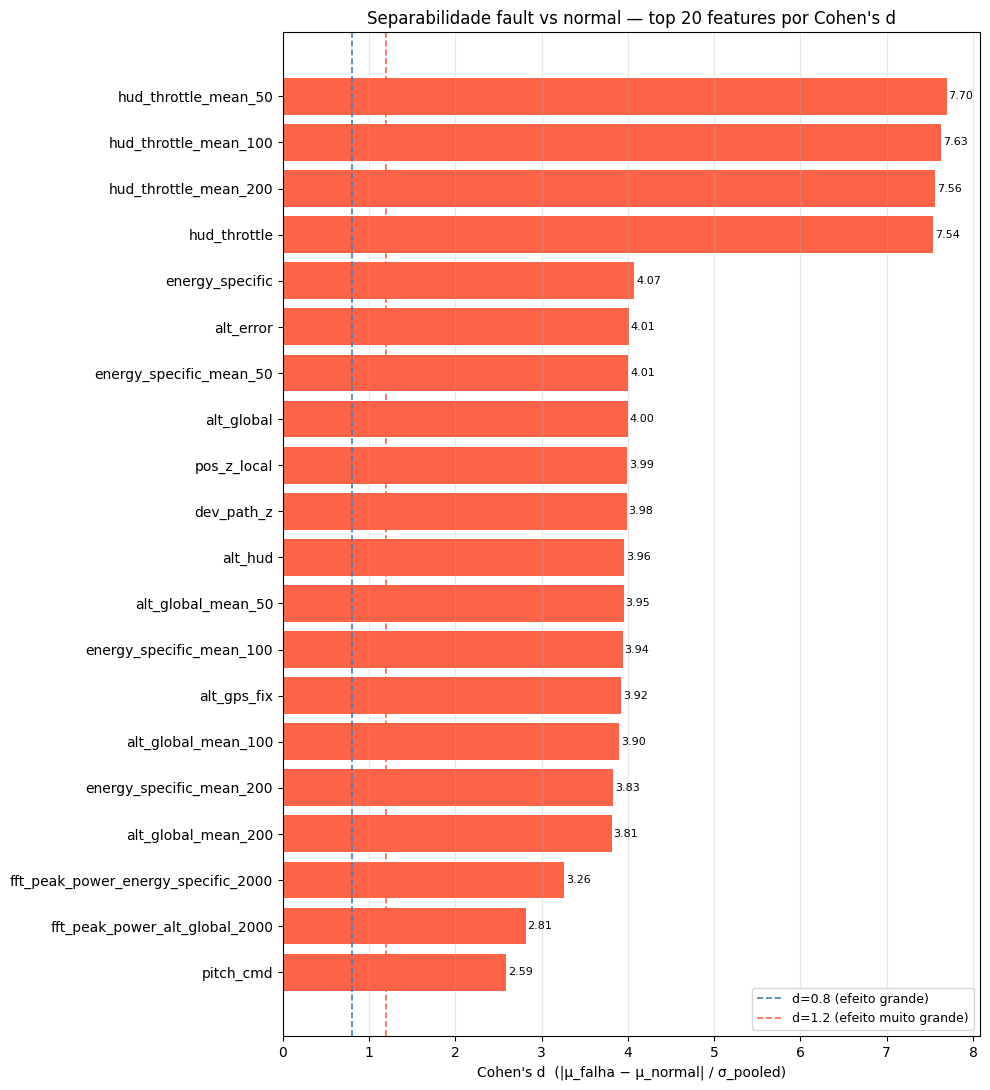

Features com d ≥ 1.2 (efeito muito grande): 20
  hud_throttle_mean_50: d=7.70
  hud_throttle_mean_100: d=7.63
  hud_throttle_mean_200: d=7.56
  hud_throttle: d=7.54
  energy_specific: d=4.07
  alt_error: d=4.01
  energy_specific_mean_50: d=4.01
  alt_global: d=4.00
  pos_z_local: d=3.99
  dev_path_z: d=3.98
  alt_hud: d=3.96
  alt_global_mean_50: d=3.95
  energy_specific_mean_100: d=3.94
  alt_gps_fix: d=3.92
  alt_global_mean_100: d=3.90
  energy_specific_mean_200: d=3.83
  alt_global_mean_200: d=3.81
  fft_peak_power_energy_specific_2000: d=3.26
  fft_peak_power_alt_global_2000: d=2.81
  pitch_cmd: d=2.59


In [4]:
# Calcula Cohen's d para todas as features e visualiza as selecionadas
normal_grp = df.loc[df[TARGET_COL] == 0, features]
fault_grp  = df.loc[df[TARGET_COL] == 1, features]

n0, n1 = len(normal_grp), len(fault_grp)
mean_diff  = (fault_grp.mean() - normal_grp.mean()).abs()
pooled_std = np.sqrt(
    ((n0 - 1) * normal_grp.std() ** 2 + (n1 - 1) * fault_grp.std() ** 2) / (n0 + n1 - 2)
).replace(0, np.nan)
cohens_d = (mean_diff / pooled_std).fillna(0)

top_scores = cohens_d[top_features].sort_values(ascending=True)

# Convenção: d < 0.2 pequeno | 0.2–0.8 médio | 0.8–1.2 grande | > 1.2 muito grande
def d_color(d):
    if d >= 1.2: return "tomato"
    if d >= 0.8: return "steelblue"
    return "lightsteelblue"

colors = [d_color(v) for v in top_scores.values]

fig, ax = plt.subplots(figsize=(10, N_TOP_FEATURES * 0.5 + 1))
ax.barh(top_scores.index, top_scores.values, color=colors)
ax.axvline(0.8, color="steelblue", linestyle="--", linewidth=1.2, label="d=0.8 (efeito grande)")
ax.axvline(1.2, color="tomato",    linestyle="--", linewidth=1.2, label="d=1.2 (efeito muito grande)")
ax.set_xlabel("Cohen's d  (|μ_falha − μ_normal| / σ_pooled)")
ax.set_title(f"Separabilidade fault vs normal — top {N_TOP_FEATURES} features por Cohen's d")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="x")

for i, (feat, val) in enumerate(zip(top_scores.index, top_scores.values)):
    ax.text(val + 0.02, i, f"{val:.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Features com efeito muito grande
muito_grandes = top_scores[top_scores >= 1.2]
print(f"Features com d ≥ 1.2 (efeito muito grande): {len(muito_grandes)}")
for f, d in muito_grandes.sort_values(ascending=False).items():
    print(f"  {f}: d={d:.2f}")

## Passo 2 — Sliding windows

Cada amostra é o achatamento dos últimos `window_size` timesteps.
A 100 Hz, `window_size=20` captura 0.2 segundos de contexto temporal.

In [5]:
X, y = create_windows(df, WINDOW_SIZE, top_features, TARGET_COL)
print(f"X shape: {X.shape}  (n_amostras, window_size × n_features)")
print(f"y shape: {y.shape}")
print(f"Positivos (falha): {y.sum()} ({y.mean()*100:.1f}%)")

X shape: (22011, 400)  (n_amostras, window_size × n_features)
y shape: (22011,)
Positivos (falha): 3220.0 (14.6%)


## Passo 3 — Split temporal e treino (novelty detection puro)

O split é **temporal** (sem shuffle): os primeiros 70% para treino, os últimos 30% para teste.

Além do split temporal, filtramos o treino para conter **apenas janelas sem falha** (`y == 0`).
O Isolation Forest é um detector de novidade: ele aprende a densidade da distribuição de treino
e sinaliza pontos distantes dela como anomalias. Treinar com dados contaminados (janelas de falha
misturadas ao normal) incorpora a assinatura da falha na "normalidade" aprendida, degradando
a sensibilidade do detector.

In [6]:
X_all, X_test, y_all, y_test = split_windows(X, y, train_ratio=TRAIN_RATIO)
timestamps = df[TIMESTAMP_COL].values[WINDOW_SIZE:]
split_idx  = int(len(timestamps) * TRAIN_RATIO)
ts_test    = timestamps[split_idx:]

# Novelty detection puro: treina apenas com janelas normais.
# O modelo aprende o que é voo saudável e detecta qualquer desvio.
normal_mask      = y_all == 0
X_train, y_train = X_all[normal_mask], y_all[normal_mask]

print(f"Train (antes do filtro): {X_all.shape} | {int(y_all.sum())} falhas")
print(f"Train (só normal):       {X_train.shape} | {int(y_train.sum())} falhas")
print(f"Test:                    {X_test.shape}  | {int(y_test.sum())} falhas")

Train (antes do filtro): (15407, 400) | 0 falhas
Train (só normal):       (15407, 400) | 0 falhas
Test:                    (6604, 400)  | 3220 falhas


In [7]:
model = train_isolation_forest(X_train, contamination=CONTAMINATION, n_estimators=N_ESTIMATORS)
print("Modelo treinado!")

Modelo treinado!


## Passo 4 — Avaliação

In [8]:
metrics = evaluate_model(model, X_test, y_test, ts_test)
print(f"Falha real:     {metrics.get('real_fault_time_s', 'N/A'):.2f}s")
print(f"Detecao:        {metrics.get('predicted_fault_time_s', 'N/A'):.2f}s")
print(f"Latencia:       {metrics.get('detection_latency_s', 'N/A'):.2f}s")

Falha real:     115.31s
Detecao:        116.50s
Latencia:       1.19s


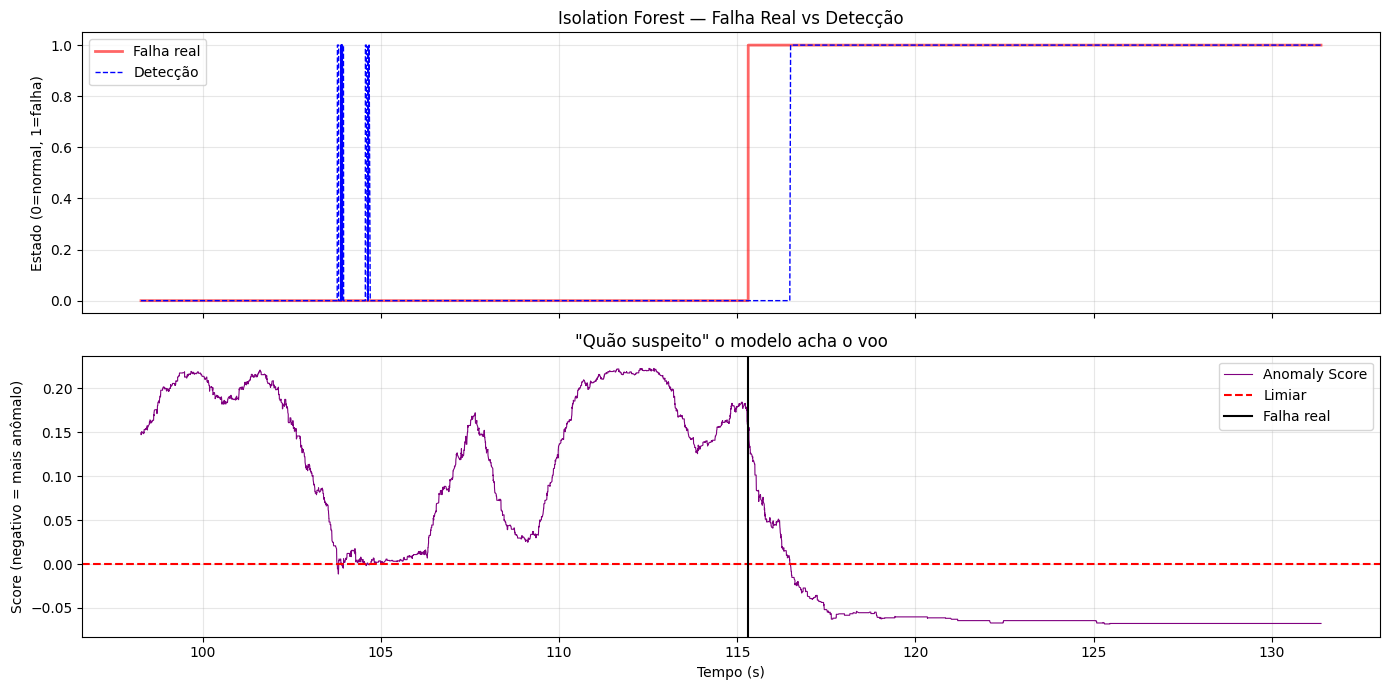

In [9]:
# Predicoes e scores
raw_preds = model.predict(X_test)
y_pred = np.where(raw_preds == -1, 1, 0)
scores = model.decision_function(X_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Painel 1: falha real vs detectada
axes[0].plot(ts_test, y_test, color="red", alpha=0.6, linewidth=2, label="Falha real")
axes[0].plot(ts_test, y_pred, color="blue", linestyle="--", linewidth=1, label="Detecção")
axes[0].set_ylabel("Estado (0=normal, 1=falha)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Isolation Forest — Falha Real vs Detecção")

# Painel 2: anomaly score
axes[1].plot(ts_test, scores, color="purple", linewidth=0.8, label="Anomaly Score")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="Limiar")
if metrics.get("real_fault_time_s"):
    axes[1].axvline(metrics["real_fault_time_s"], color="black", linewidth=1.5, label="Falha real")
axes[1].set_ylabel("Score (negativo = mais anômalo)")
axes[1].set_xlabel("Tempo (s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('"Quão suspeito" o modelo acha o voo')

plt.tight_layout()
plt.show()

---
**Próximo:** `03_01_model2.ipynb` → tuning do parâmetro `contamination` para otimizar a latência de detecção.